In [58]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras import regularizers
from tensorflow.keras.datasets import mnist

In [59]:
(x_train,y_train),(x_test,y_test) = mnist.load_data()

In [60]:
x_train.shape

(60000, 28, 28)

In [61]:
x_test.shape

(10000, 28, 28)

In [62]:
y_train.shape

(60000,)

In [63]:
y_test.shape

(10000,)

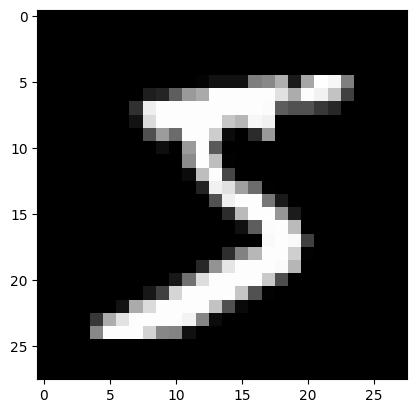

In [64]:
plt.imshow(x_train[0], cmap='gray')
plt.show()

In [65]:
print("Label:", y_train[0])

Label: 5


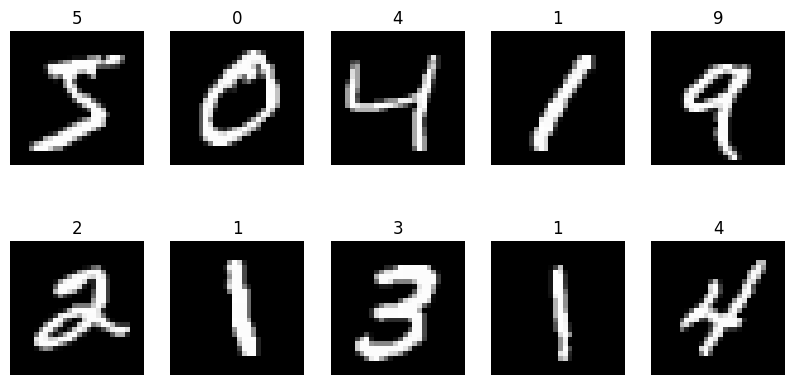

In [66]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()

In [67]:
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0
Maximum pixel value: 255


In [68]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [69]:
print("Minimum:", x_train.min())
print("Maximum:", x_train.max())

Minimum: 0.0
Maximum: 1.0


In [70]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [71]:
print("X Train:", x_train.shape)
print("X Test:", x_test.shape)

X Train: (60000, 28, 28, 1)
X Test: (10000, 28, 28, 1)


In [73]:
cnn = Sequential()

cnn.add(
    tf.keras.Input(shape=(28, 28, 1))
)

cnn.add(
    Conv2D(
        32,
        (3, 3),
        activation='relu'
    )
)

In [74]:
cnn.add(
    MaxPooling2D(pool_size=(2, 2))
)

In [75]:
cnn.add(Flatten())

In [76]:
cnn.add(
    Dense(
        128,
        activation='relu'
    )
)

In [77]:
cnn.add(
    Dense(
        10,
        activation='softmax'
    )
)

In [78]:
cnn.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [79]:
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [80]:
from tensorflow.keras.callbacks import EarlyStopping

In [81]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [82]:
history = cnn.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9549 - loss: 0.1531 - val_accuracy: 0.9813 - val_loss: 0.0578
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9833 - loss: 0.0541 - val_accuracy: 0.9791 - val_loss: 0.0585
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9893 - loss: 0.0354 - val_accuracy: 0.9843 - val_loss: 0.0455
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9926 - loss: 0.0233 - val_accuracy: 0.9859 - val_loss: 0.0454
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9949 - loss: 0.0169 - val_accuracy: 0.9867 - val_loss: 0.0409
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9968 - loss: 0.0109 - val_accuracy: 0.9851 - val_loss: 0.0521
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - accuracy: 0.9968 - loss: 0.0091 - val_accuracy: 0.9870 - val_loss: 0.0457
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9976 -

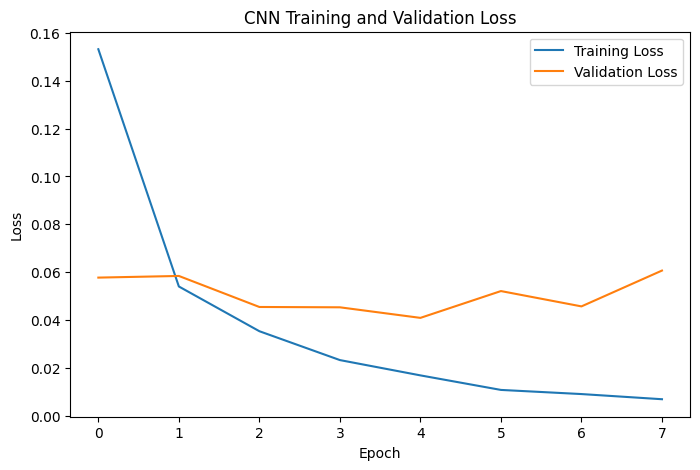

In [83]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training and Validation Loss')
plt.legend()

plt.show()

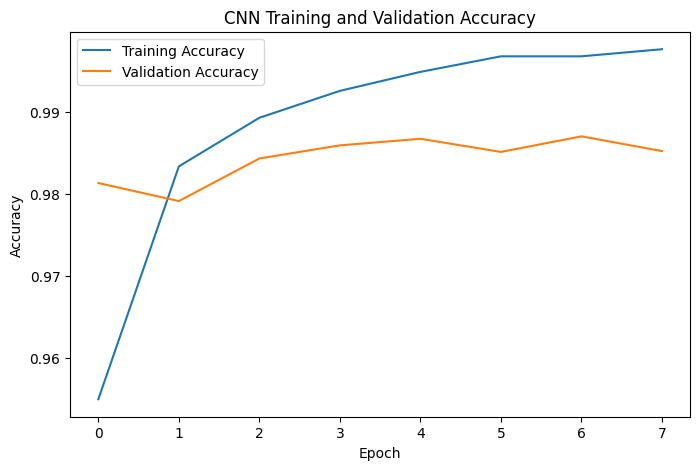

In [84]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Training and Validation Accuracy')
plt.legend()

plt.show()

In [85]:
loss, accuracy = cnn.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

Test Loss: 0.04094691947102547
Test Accuracy: 0.9866999983787537


In [86]:
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 98.67%


In [87]:
y_pred_prob = cnn.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [88]:
y_pred = np.argmax(y_pred_prob, axis=1)

In [89]:
print("Actual:   ", y_test[:10])
print("Predicted:", y_pred[:10])

Actual:    [7 2 1 0 4 1 4 9 5 9]
Predicted: [7 2 1 0 4 1 4 9 5 9]


In [90]:
from sklearn.metrics import confusion_matrix

In [91]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 977    0    0    1    0    0    1    0    0    1]
 [   1 1123    1    1    1    0    3    3    2    0]
 [   2    2 1019    0    2    0    0    6    1    0]
 [   0    0    0 1004    0    4    0    0    2    0]
 [   0    0    0    0  969    0    0    0    0   13]
 [   1    0    1    8    0  878    3    0    0    1]
 [   9    2    0    1    7    2  935    0    2    0]
 [   0    0    4    3    0    0    0 1014    1    6]
 [   2    0    2    2    2    3    0    2  956    5]
 [   0    1    0    3    5    2    0    6    0  992]]


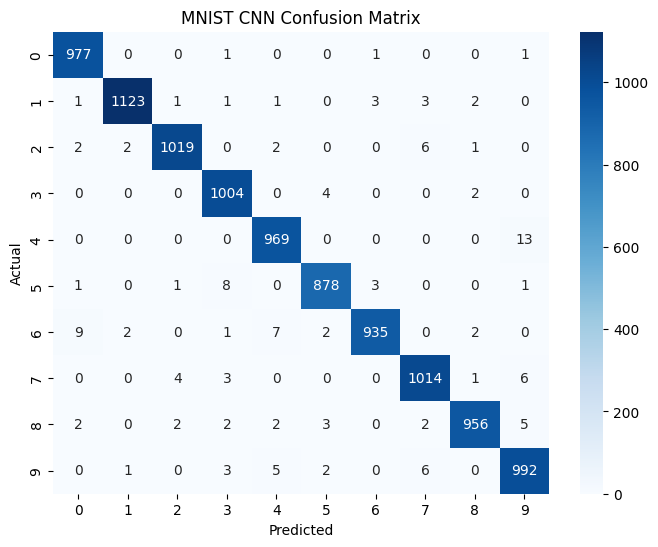

In [92]:
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('MNIST CNN Confusion Matrix')

plt.show()

In [93]:
from sklearn.metrics import classification_report

In [94]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.98      0.99      0.99      1010
           4       0.98      0.99      0.98       982
           5       0.99      0.98      0.99       892
           6       0.99      0.98      0.98       958
           7       0.98      0.99      0.98      1028
           8       0.99      0.98      0.99       974
           9       0.97      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [95]:
index = 100

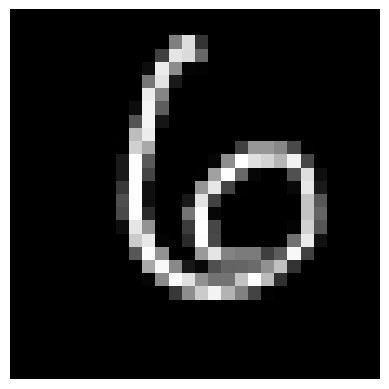

In [96]:
plt.imshow(x_test[index].reshape(28, 28), cmap='gray')
plt.axis('off')
plt.show()

In [97]:
prediction = cnn.predict(
    x_test[index:index+1]
)

predicted_digit = np.argmax(prediction)

print("Actual Digit:", y_test[index])
print("Predicted Digit:", predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
Actual Digit: 6
Predicted Digit: 6


In [98]:
print(prediction)

[[1.8943314e-05 3.0991727e-09 4.4663901e-11 5.7081884e-11 1.8914367e-08
  1.8930031e-08 9.9998105e-01 9.6476674e-11 2.8549845e-08 8.0008915e-09]]


In [99]:
cnn.save("mnist_cnn_model.keras")